# OpenCV: Computer Vision with Python
---

### Introduction
---

OpenCV (Open Source Computer Vision Library) is an open-source computer vision and machine learning software library. It has over 2500
optimized algorithms for real-time image and video processing.

### Installation
Install OpenCV using

In [ ]:
pip install opencv-python 

## Basic Imports

In [1]:
import cv2

In [10]:
import numpy as np

In [11]:
import matplotlib.pyplot as plt

## 1. Read the Image

In [26]:
# Load image
image = cv2.imread("dog1.jpg")

if image is None:
    print("Image not found, Check image path and name , correct this.")
else:
    print("Image Loaded Successfully.")
    print(f"Image type : {type(image)}")

Image Loaded Successfully.
Image type : <class 'numpy.ndarray'>


# 2. Display the image

OpenCV reads images in **BGR** (Blue, Green, Red).
<br>
Matplotlib shows images in **RGB** (Red, Green, Blue).

So we convert **BGR → RGB** before showing.

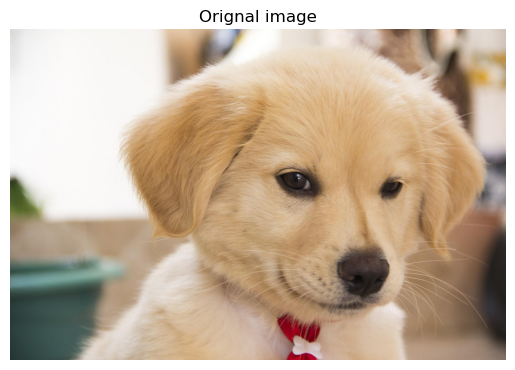

In [27]:
if image is not None:
    img_rgb = cv2.cvtColor(image , cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title("Orignal image")
    plt.show()

# 3. Understand image size (shape)

`img.shape` returns:
- **Height** (How tall)
- **Width** (How wide)
- **Channels** (Colors)

For a color image: 

- channel = **3** (R , G , B) 

For grayscale image:

- channels = **1**

In [28]:
if image is not None:
    h , w , c = image.shape
    print("Height:", h)
    print("Width :", w)
    print("Channels:", c)

Height: 853
Width : 1280
Channels: 3


# 4. Pixels are numbers
A pixel is a tiny dot.

- In color image : each pixel hai **3 numbers** (R, G , B)
- Example : `[12 , 200 , 30]`

Let's print the first pixel (top-Level).

In [29]:
if image is not None:
    print("Top left pixel : " , image[1,1])

Top left pixel :  [216 218 219]


# 5. Convert to Grayscale (Black & White)

Why it matters:

- It is simpler for the computer
- Many CV tasks start with grayscale

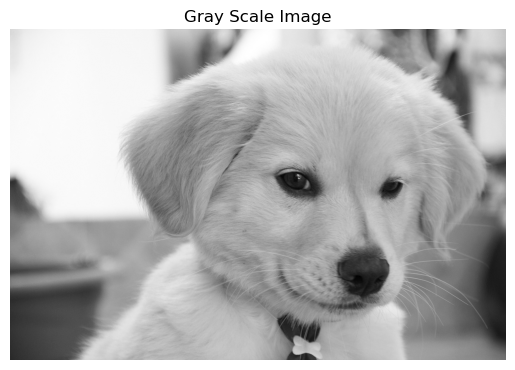

In [30]:
if image is not None:
    gray = cv2.cvtColor(image , cv2.COLOR_BGR2GRAY)
    plt.imshow(gray , cmap="gray")
    plt.axis("off")
    plt.title("Gray Scale Image")
    plt.show()

# 6. Resize the image
Why resize?

- Smaller image = faster processing
- In AI models, input size is usually fixed (example: 640×640)

We will resize to 300×300

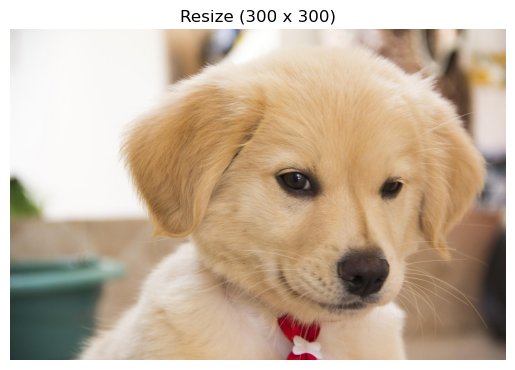

In [31]:
if image is not None:
    resize = cv2.resize(image , (300 , 300))
    resize_rgb = cv2.cvtColor(image , cv2.COLOR_BGR2RGB)
    plt.imshow(resize_rgb)
    plt.axis("off")
    plt.title("Resize (300 x 300)")
    plt.show()

# 7.Blur (make image smooth)

**Blurring** is an image preprocessing step used in Machine Learning and Computer Vision to **smooth an image and reduce noise** (tiny unwanted details).

### What does blur do?

* It softens sharp edges
* It removes small dots, grain, or random pixels (noise)
* It makes important shapes easier for the model to understand

### Simple analogy:

> Blurring is like **looking through slightly foggy glass** — small details disappear, but the main objects are still visible.

### Why blur is used in ML:

* Reduces noise that can confuse the model
* Improves edge detection and feature extraction
* Helps models focus on **important patterns**, not tiny distractions



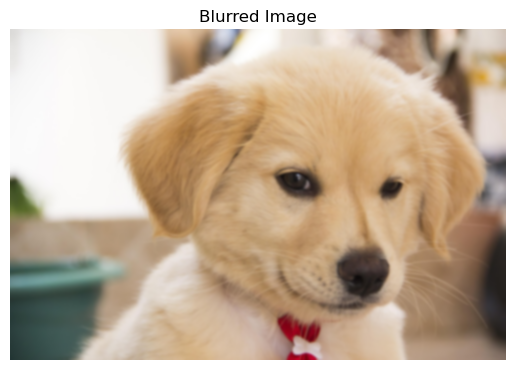

In [34]:
if image is not None:
    blur = cv2.GaussianBlur(image , (15, 15) , 0)
    blur_rgb = cv2.cvtColor(blur , cv2.COLOR_BGR2RGB)

    plt.imshow(blur_rgb)
    plt.axis("off")
    plt.title("Blurred Image")
    plt.show()

# 8. Edge Detection (WOW moment)

Edges are the **boundaries** of objects.
<br>
Edge detection is used in:

- security cameras
- defect detection
- medical scans
- self-driving

We use **Canny** edges.

`edges = cv2.Canny(gray, 100, 200)`

This line **detects edges** in an image using the **Canny Edge Detection** algorithm.

### What is happening?

* `cv2.Canny()` → OpenCV function for **edge detection**
* `gray` → **grayscale image**
  (Canny works on gray images, not color)
* `100` → **lower threshold**
* `200` → **upper threshold**
* `edges` → output image showing **only edges** (white lines on black background)

---

### Thresholds explained (MOST IMPORTANT)

| Value        | Meaning               |
| ------------ | --------------------- |
| `100` (low)  | Weak edges start      |
| `200` (high) | Strong edges accepted |

Pixels with:

* gradient > 200 → **definitely an edge**
* gradient < 100 → **not an edge**
* between 100–200 → edge only if connected to strong edge

### Simple analogy:

> Like outlining objects with a pencil — only the **boundaries** are drawn, everything else is ignored.


### Why we use Canny in ML / CV:

* Detect object boundaries
* Shape detection
* Preprocessing for object recognition


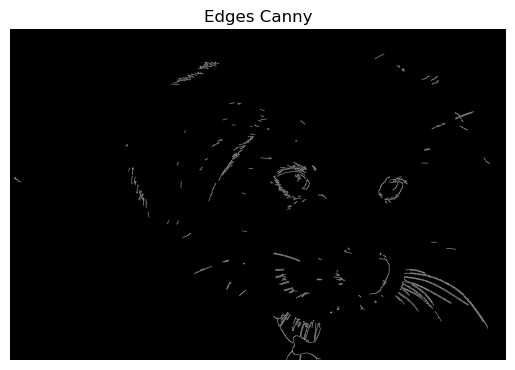

In [38]:
if gray is not None:
    edges = cv2.Canny(gray , 100 , 200)

    plt.imshow(edges , cmap="gray")
    plt.axis("off")
    plt.title("Edges Canny")
    plt.show()

# 9. Save the processed images

We will save: 

- grayscale
- resize
- blurred
- edges

They will be saved in the same folder as your notebook (or wherever you run it).